# 문서 그룹별 `-었-` 결합 분포 박스플롯

문서별 `docu_었_결합률`과 `docu_었_결합_로그오즈비`를 category 또는 다른 분류 컬럼별로 비교한다.

박스플롯의 상자는 제1사분위수(Q1, 25%)부터 제3사분위수(Q3, 75%)까지이며, 상자 안의 선은 중앙값(Q2, 50%)이다. 기본 수염은 Q1·Q3에서 `1.5 × IQR` 이내의 관측값까지 표시하고, 그 밖의 값은 이상치 점으로 표시한다.

## 선행 작업

`세종문어_document_정보_통합(수정).csv` 파일을 직접 읽어 문서 분류 정보와 통계 지표를 함께 사용한다.


In [51]:
from pathlib import Path
from datetime import datetime
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import sys
ROOT = Path.cwd().parents[0]
sys.path.append(str(ROOT))
from stats.filtering import apply_filters, FilterValue, has_value, _topn_values


## 1. 분석 설정

보통은 이 셀만 수정하면 된다.

- `GROUP_COL`: `category`, `매체`, `내용`, `분류기호`, `category2` 등
- `MIN_DOC_SIZE`, `MAX_DOC_SIZE`: 분석 대상 문장 수에 따른 문서 포함·제외
- `INCLUDE_GROUPS`, `EXCLUDE_GROUPS`: 특정 그룹 선택
- `MIN_DOCS_PER_GROUP`: 그룹당 최소 문서 수


In [ ]:
# ---------- 입력 파일 ----------
DATA_CSV = Path(r"C:\Users\whyeon\Projects\__data\세종문어_document_정보_통합(수정).csv")

# ---------- 그룹 기준 ----------
GROUP_COL = "category"       # 예: "category", "매체", "내용", "분류기호", "category2"
CUSTOM_GROUP_COLS = []       # 병합해서 새 그룹을 만들 컬럼. 예: ["category", "매체"]
CUSTOM_GROUP_NAME = "사용자_그룹"
CUSTOM_GROUP_SEPARATOR = "_"

# None이면 전체 그룹을 사용한다.
INCLUDE_GROUPS = None        # 예: ["보도해설", "허구일반", "인문사회"]
EXCLUDE_GROUPS = []          # 예: ["기타"]
MIN_DOCS_PER_GROUP = 10

# ---------- 문서 크기 필터 ----------
SIZE_COL = "docu_base_count_not_quote"
MIN_DOC_SIZE = 1             # 0문장 문서를 제외. 예: 10, 20, 50 등으로 변경
MAX_DOC_SIZE = None          # 상한이 필요하면 정수 입력. 예: 500

# ---------- 그래프 설정 ----------
METRICS = ["docu_었_결합률", "docu_었_결합_로그오즈비"]
RATE_AS_PERCENT = True
BOXPLOT_ORIENTATION = "vertical"  # "horizontal" 또는 "vertical"
BOXPLOT_ORIENTATION = BOXPLOT_ORIENTATION.lower().strip()
if BOXPLOT_ORIENTATION not in {"horizontal", "vertical"}:
    raise ValueError("BOXPLOT_ORIENTATION은 'horizontal' 또는 'vertical'이어야 합니다.")
HORIZONTAL = BOXPLOT_ORIENTATION != "vertical"
SHOW_FLIERS = True           # 1.5×IQR 밖의 이상치 표시
WHIS = 1.5                   # 수염 길이. (0, 100)으로 바꾸면 최솟값~최댓값
SHOW_POINTS = False          # 모든 문서의 개별 점을 겹쳐 표시
MAX_POINTS_PER_GROUP = 500   # SHOW_POINTS=True일 때 그룹별 최대 점 수
RANDOM_SEED = 42

# 그룹 순서: "median", "count", "alphabetical", "custom"
ORDER_MODE = "median"
ORDER_BY_METRIC = "docu_었_결합_로그오즈비"
ASCENDING = True
CUSTOM_ORDER = []

# 특정 지표의 축 범위를 제한하려면 지정한다. None은 자동 범위.
AXIS_LIMITS = {
    "docu_었_결합률": None,             # 백분율 표시일 때 예: (0, 100)
    "docu_었_결합_로그오즈비": None,   # 예: (-5, 5)
}

# ---------- 저장 설정 ----------
SAVE_FIGURE = True
FIGURE_DIR = Path(r"C:\Users\whyeon\Projects\__data\document_boxplot")
FIGURE_DPI = 180


In [55]:
def set_korean_font():
    """현재 시스템에서 사용 가능한 대표 한글 글꼴을 설정한다."""
    candidates = ["Malgun Gothic", "맑은 고딕", "AppleGothic", "NanumGothic"]
    installed = {font.name for font in font_manager.fontManager.ttflist}
    selected = next((name for name in candidates if name in installed), None)
    if selected:
        plt.rcParams["font.family"] = selected
        print(f"한글 글꼴: {selected}")
    else:
        print("주의: 대표 한글 글꼴을 찾지 못했습니다. 그래프에서 한글이 깨질 수 있습니다.")
    plt.rcParams["axes.unicode_minus"] = False


set_korean_font()


한글 글꼴: Malgun Gothic


In [56]:
if not DATA_CSV.exists():
    raise FileNotFoundError(f"통합 데이터 파일이 없습니다: {DATA_CSV}")

df = pd.read_csv(DATA_CSV, low_memory=False)

required_cols = {"docu_id", SIZE_COL, *METRICS}
missing_cols = sorted(required_cols - set(df.columns))
if missing_cols:
    raise ValueError(f"통합 데이터 파일에 필요한 컬럼이 없습니다: {missing_cols}")

# category2가 요청되었지만 원본에 없으면 category와 매체로 만든다.
if GROUP_COL == "category2" and "category2" not in df.columns:
    needed = {"category", "매체"}
    if not needed.issubset(df.columns):
        raise ValueError("category2 생성에 category와 매체 컬럼이 필요합니다.")
    df["category2"] = (
        df["category"].astype("string").str.strip()
        + "_"
        + df["매체"].astype("string").str.strip()
    )

# 여러 컬럼을 결합한 사용자 그룹을 만들 수 있다.
active_group_col = GROUP_COL
if CUSTOM_GROUP_COLS:
    missing_custom = sorted(set(CUSTOM_GROUP_COLS) - set(df.columns))
    if missing_custom:
        raise ValueError(f"사용자 그룹 생성 컬럼이 없습니다: {missing_custom}")
    df[CUSTOM_GROUP_NAME] = (
        df[CUSTOM_GROUP_COLS]
        .astype("string")
        .apply(lambda col: col.str.strip())
        .agg(CUSTOM_GROUP_SEPARATOR.join, axis=1)
    )
    active_group_col = CUSTOM_GROUP_NAME

if active_group_col not in df.columns:
    raise ValueError(
        f"그룹 컬럼 '{active_group_col}'이 통합 데이터 파일에 없습니다.\n"
        f"사용 가능한 컬럼: {df.columns.tolist()}"
    )

print(f"통합 데이터: {len(df):,}행")
print(f"분류 기준: {active_group_col}")


통합 데이터: 33,155행
분류 기준: category


In [57]:
df.head()

,docu_id,file_id,docu_num,category,매체,category_매체,파일제목,head,내용,저자,...,file_head_count,file_body_count,file_body_has_E_count,file_body_not_quote_count,file_body_not_quote_and_었_count,file_었_결합_오즈비,file_었_결합_로그오즈비,file_었_결합률,file_었_결합_등급,file_었_결합_성향
0,AA0001.001,AA0001,1.0,보도해설,신문,보도해설_신문,조선일보 생활(93),엠마누엘 웅가로 / 의상서 실내 장식품으로… 디자인 세계 넓혀,"보도·해설-생활,과학",조선일보사,...,164,1226,1083,951,260,0.520896,-0.652204,0.273396,2,회피
1,GO0362.007,GO0362,7.0,허구아동,책,허구아동_책,똘배가 보고 온 달나라,8,"교육자료,아동도서/상상적산문",권정생 외,...,34,3578,3349,2554,1898,4.024373,1.392369,0.743148,4,선호
2,HO0100.590,HO0100,590.0,인문사회,책,인문사회_책,과천향토사,3)두레놀이,"총류,일반",과천문화원,...,959,9556,9165,8747,2939,0.698501,-0.358819,0.336001,3,중립
3,HO0124.064,HO0124,64.0,인문사회,책,인문사회_책,우리 학문의 길,세 단계의 작업,"인문,일반",조동일,...,106,3873,3859,3786,1178,0.624479,-0.470837,0.311146,3,중립
4,AA0001.005,AA0001,5.0,보도해설,신문,보도해설_신문,조선일보 생활(93),자동차 경기장 모터파크 / 국내 첫 아스팔트포장… 자연농원서 9월개장,"보도·해설-생활,과학",조선일보사,...,164,1226,1083,951,260,0.520896,-0.652204,0.273396,2,회피


In [58]:
df_plot = df.copy()
df_plot[active_group_col] = df_plot[active_group_col].astype("string").str.strip()

#기타 필터
''' 
filters: Dict[str, FilterValue] = {
    "category": ["강의", "낭독"],
    "outcome_total": lambda s: s >= 500,
    "outcome_total": lambda s: (s >= 20) & (~s.isin(list([4999, 2999]))),
    }

filtered_df = apply_filters(df, filters)

df_plot
'''
FILTER = {"docu_dominant_EN_No": 1101}
df_plot = apply_filters(df_plot, FILTER)

# 문서 크기 필터
size = pd.to_numeric(df_plot[SIZE_COL], errors="coerce")
mask = size.ge(MIN_DOC_SIZE)
if MAX_DOC_SIZE is not None:
    mask &= size.le(MAX_DOC_SIZE)
df_plot = df_plot.loc[mask].copy()

# 그룹 선택 필터
df_plot = df_plot.dropna(subset=[active_group_col])
if INCLUDE_GROUPS is not None:
    df_plot = df_plot[df_plot[active_group_col].isin(INCLUDE_GROUPS)].copy()
if EXCLUDE_GROUPS:
    df_plot = df_plot[~df_plot[active_group_col].isin(EXCLUDE_GROUPS)].copy()

# 지표를 숫자로 변환하고 결측값 제거
for metric in METRICS:
    metric_values = df_plot[metric]
    if metric_values.astype("string").str.contains("%", regex=False, na=False).any():
        metric_values = metric_values.astype("string").str.replace("%", "", regex=False).str.strip()
        df_plot[metric] = pd.to_numeric(metric_values, errors="coerce") / 100
    else:
        df_plot[metric] = pd.to_numeric(metric_values, errors="coerce")
df_plot = df_plot.dropna(subset=METRICS)

# 문서 수가 너무 적은 그룹 제외
group_counts = df_plot[active_group_col].value_counts()
valid_groups = group_counts[group_counts >= MIN_DOCS_PER_GROUP].index
df_plot = df_plot[df_plot[active_group_col].isin(valid_groups)].copy()

if df_plot.empty:
    raise ValueError("필터 적용 후 남은 문서가 없습니다. 분석 설정을 완화하세요.")

print(f"분석 문서 수: {len(df_plot):,}")
print(f"분석 그룹 수: {df_plot[active_group_col].nunique():,}")
print(f"문서 크기 범위: {df_plot[SIZE_COL].min():,}~{df_plot[SIZE_COL].max():,}")
df_plot[active_group_col].value_counts().sort_index()


분석 문서 수: 17,342
분석 그룹 수: 9
문서 크기 범위: 10~5,703


category
보도해설    5064
사설      1605
인문사회    6189
자연       682
체험기술    1054
총류       609
칼럼       941
허구아동      59
허구일반    1139
Name: count, dtype: Int64

In [59]:
# 사분위수 요약 함수
def make_quartile_summary(data: pd.DataFrame, group_col: str, metrics: list[str]) -> pd.DataFrame:
    rows = []
    for group, part in data.groupby(group_col, observed=True, sort=False):
        for metric in metrics:
            values = part[metric].dropna()
            q1 = values.quantile(0.25)
            median = values.quantile(0.50)
            q3 = values.quantile(0.75)
            rows.append({
                group_col: group,
                "지표": metric,
                "문서수": len(values),
                "최솟값": values.min(),
                "Q1_25%": q1,
                "중앙값_Q2_50%": median,
                "Q3_75%": q3,
                "IQR": q3 - q1,
                "최댓값": values.max(),
                "평균": values.mean(),
            })
    return pd.DataFrame(rows)


df_quartiles = make_quartile_summary(df_plot, active_group_col, METRICS)
df_quartiles.sort_values(["지표", "중앙값_Q2_50%"])


,category,지표,문서수,최솟값,Q1_25%,중앙값_Q2_50%,Q3_75%,IQR,최댓값,평균
15,자연,docu_었_결합_로그오즈비,682,-5.579806,-2.969934,-2.313153,-0.711531,2.258403,1.935417,-1.869144
17,사설,docu_었_결합_로그오즈비,1605,-3.991634,-2.564475,-1.753538,-1.121012,1.443463,1.019096,-1.792514
11,체험기술,docu_었_결합_로그오즈비,1054,-4.678168,-2.239090,-1.214545,-0.166552,2.072538,3.693265,-1.145320
9,칼럼,docu_었_결합_로그오즈비,941,-4.383713,-2.072044,-0.973367,-0.079536,1.992508,3.822483,-0.965477
13,총류,docu_었_결합_로그오즈비,609,-4.248879,-1.688998,-0.926841,-0.079536,1.609462,3.544840,-0.893187
1,인문사회,docu_었_결합_로그오즈비,6189,-4.827537,-2.276809,-0.906243,0.412965,2.689774,4.436889,-0.851175
3,보도해설,docu_었_결합_로그오즈비,5064,-4.850400,-1.753525,-0.654907,0.325938,2.079463,3.989545,-0.615230
5,허구일반,docu_었_결합_로그오즈비,1139,-4.068601,0.541622,1.254285,1.913907,1.372286,4.333339,1.126192
7,허구아동,docu_었_결합_로그오즈비,59,-2.553603,1.129014,1.698403,2.446355,1.317341,3.989600,1.644415
14,자연,docu_었_결합률,682,0.000000,0.000000,0.067000,0.261750,0.261750,0.833000,0.156974


In [60]:
# 그룹 순서를 결정하는 함수
def get_group_order(data: pd.DataFrame, group_col: str) -> list[str]:
    groups = data[group_col].dropna().unique().tolist()

    if ORDER_MODE == "custom":
        specified = [group for group in CUSTOM_ORDER if group in groups]
        remainder = sorted(set(groups) - set(specified))
        return specified + remainder
    if ORDER_MODE == "alphabetical":
        return sorted(groups, reverse=not ASCENDING)
    if ORDER_MODE == "count":
        order = data[group_col].value_counts().sort_values(ascending=ASCENDING)
        return order.index.tolist()
    if ORDER_MODE == "median":
        if ORDER_BY_METRIC not in data.columns:
            raise ValueError(f"정렬 지표가 없습니다: {ORDER_BY_METRIC}")
        order = data.groupby(group_col, observed=True)[ORDER_BY_METRIC].median()
        return order.sort_values(ascending=ASCENDING).index.tolist()

    raise ValueError(f"지원하지 않는 ORDER_MODE: {ORDER_MODE}")


group_order = get_group_order(df_plot, active_group_col)
group_order


['자연', '사설', '체험기술', '칼럼', '총류', '인문사회', '보도해설', '허구일반', '허구아동']

In [61]:
# 그래프용 지표와 라벨을 반환하는 함수
def metric_for_plot(data: pd.DataFrame, metric: str) -> tuple[pd.Series, str]:
    values = data[metric].astype(float)
    label = metric
    if metric == "docu_었_결합률" and RATE_AS_PERCENT:
        values = values * 100
        label = "었 결합률(%)"
    return values, label

# 박스플롯 그리기 함수
def draw_group_boxplot(
    data: pd.DataFrame,
    group_col: str,
    metric: str,
    order: list[str],
    ax,
):
    plot_data = data.copy()
    plot_data["_plot_value"], axis_label = metric_for_plot(plot_data, metric)
    values_by_group = [
        plot_data.loc[plot_data[group_col].eq(group), "_plot_value"].dropna().to_numpy()
        for group in order
    ]

    common = dict(
        showfliers=SHOW_FLIERS,
        whis=WHIS,
        patch_artist=True,
        medianprops={"color": "#9b2226", "linewidth": 1.8},
        boxprops={"facecolor": "#94d2bd", "edgecolor": "#005f73", "linewidth": 1.1},
        whiskerprops={"color": "#005f73", "linewidth": 1.0},
        capprops={"color": "#005f73", "linewidth": 1.0},
        flierprops={"marker": ".", "markersize": 3, "alpha": 0.30, "markeredgecolor": "#6c757d"},
    )

    if HORIZONTAL:
        ax.boxplot(values_by_group, tick_labels=order, orientation="horizontal", **common)
        ax.set_xlabel(axis_label)
        ax.set_ylabel(group_col)
    else:
        ax.boxplot(values_by_group, tick_labels=order, orientation="vertical", **common)
        ax.set_ylabel(axis_label)
        ax.set_xlabel(group_col)
        ax.tick_params(axis="x", rotation=45)

    if SHOW_POINTS:
        rng = np.random.default_rng(RANDOM_SEED)
        for position, values in enumerate(values_by_group, start=1):
            if len(values) > MAX_POINTS_PER_GROUP:
                values = rng.choice(values, size=MAX_POINTS_PER_GROUP, replace=False)
            jitter = rng.uniform(-0.12, 0.12, size=len(values))
            if HORIZONTAL:
                ax.scatter(values, position + jitter, s=7, alpha=0.18, color="#001219", zorder=3)
            else:
                ax.scatter(position + jitter, values, s=7, alpha=0.18, color="#001219", zorder=3)

    limits = AXIS_LIMITS.get(metric)
    if limits is not None:
        if HORIZONTAL:
            ax.set_xlim(*limits)
        else:
            ax.set_ylim(*limits)

    ax.set_title(f"{group_col}별 {axis_label} 분포")
    ax.grid(axis="x" if HORIZONTAL else "y", linestyle=":", alpha=0.35)


그래프 저장: C:\Users\whyeon\Projects\__data\document_boxplot\문서_었결합_박스플롯_category_docu_었_결합률_20260708_00-06-00.png


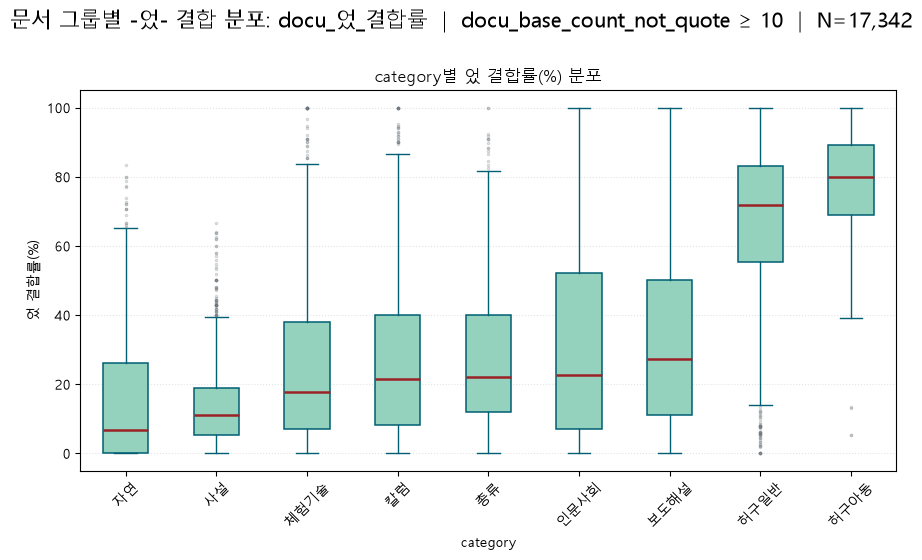

그래프 저장: C:\Users\whyeon\Projects\__data\document_boxplot\문서_었결합_박스플롯_category_docu_었_결합_로그오즈비_20260708_00-06-00.png


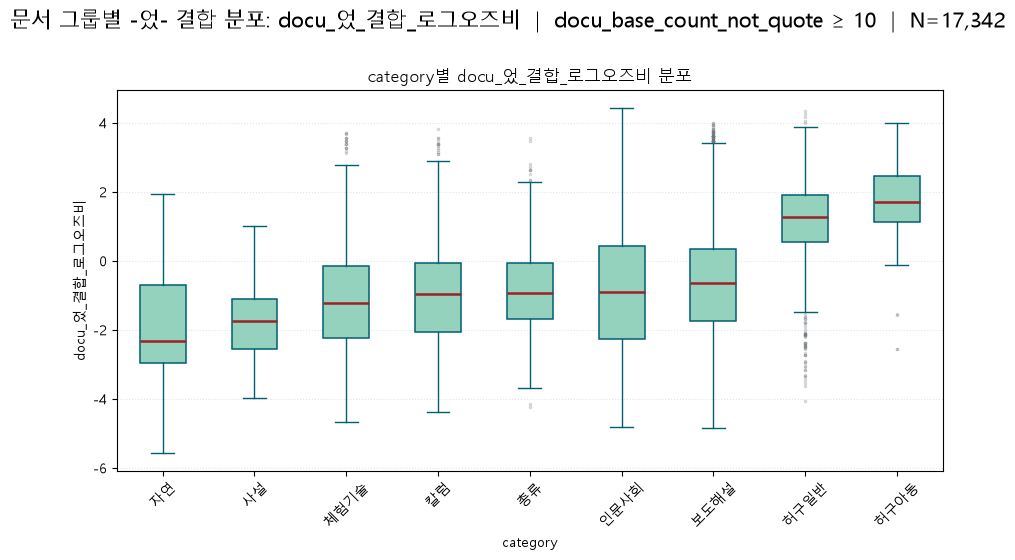

In [62]:
n_groups = len(group_order)
size_text = f"{SIZE_COL} ≥ {MIN_DOC_SIZE}"
if MAX_DOC_SIZE is not None:
    size_text += f", ≤ {MAX_DOC_SIZE}"

saved_figures = []
if SAVE_FIGURE:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H-%M-%S")
    safe_group_name = str(active_group_col).replace("/", "_").replace("\\", "_")

for metric in METRICS:
    if HORIZONTAL:
        fig_width = 9.5
        fig_height = max(5.5, 0.42 * n_groups + 2.2)
    else:
        fig_width = max(9, 0.65 * n_groups + 3)
        fig_height = 5.5

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    draw_group_boxplot(df_plot, active_group_col, metric, group_order, ax)
    fig.suptitle(
        f"문서 그룹별 -었- 결합 분포: {metric}  |  {size_text}  |  N={len(df_plot):,}",
        fontsize=15,
        y=1.01,
    )
    fig.tight_layout()

    if SAVE_FIGURE:
        safe_metric_name = str(metric).replace("/", "_").replace("\\", "_")
        saved_figure = FIGURE_DIR / f"문서_었결합_박스플롯_{safe_group_name}_{safe_metric_name}_{timestamp}.png"
        fig.savefig(saved_figure, dpi=FIGURE_DPI, bbox_inches="tight")
        saved_figures.append(saved_figure)
        print(f"그래프 저장: {saved_figure}")

    plt.show()


In [63]:
# 그래프에 사용된 문서 목록과 사분위수 요약표를 함께 저장한다.
if SAVE_FIGURE:
    timestamp = datetime.now().strftime("%Y%m%d_%H-%M-%S")
    safe_group_name = str(active_group_col).replace("/", "_").replace("\\", "_")

    summary_path = FIGURE_DIR / f"문서_었결합_사분위요약_{safe_group_name}_{timestamp}.csv"
    data_path = FIGURE_DIR / f"문서_었결합_박스플롯사용자료_{safe_group_name}_{timestamp}.csv"

    df_quartiles.to_csv(summary_path, index=False, encoding="utf-8-sig")
    df_plot[["docu_id", active_group_col, SIZE_COL, *METRICS]].to_csv(
        data_path, index=False, encoding="utf-8-sig"
    )
    print(f"사분위수 요약 저장: {summary_path}")
    print(f"그래프 사용자료 저장: {data_path}")


사분위수 요약 저장: C:\Users\whyeon\Projects\__data\document_boxplot\문서_었결합_사분위요약_category_20260708_00-06-07.csv
그래프 사용자료 저장: C:\Users\whyeon\Projects\__data\document_boxplot\문서_었결합_박스플롯사용자료_category_20260708_00-06-07.csv
